# Neural Bandit Algorithm Evaluation Framework

## Graduate Research Project
**AI & Quantum Computing Laboratory**  
**Rochester Institute of Technology**

---

## Research Framework Overview

This comprehensive evaluation framework provides rigorous analysis of neural bandit algorithms with clear categorical distinction between different operational environments:

- **Baseline Environment**: Optimal performance benchmark (Oracle)
- **Stochastic Environment**: Natural random failures and network noise
- **Adversarial Environment**: Strategic intelligent attacks and malicious targeting

## Primary Research Questions

1. **Algorithm Robustness**: How do neural bandit algorithms perform across different threat models?
2. **Comparative Analysis**: Which algorithms demonstrate superior performance in specific scenarios?
3. **Quantified Performance**: What are the exact degradation metrics under adversarial conditions?
4. **Theoretical Validation**: Do experimental results align with established regret bounds?

## Key Research Contributions

- **Systematic Environment Categorization**: Clear baseline/stochastic/adversarial taxonomy
- **Multi-Algorithm Comparative Testing**: Comprehensive evaluation across 6+ algorithms
- **Quantified Robustness Metrics**: Precise performance degradation measurements
- **Publication-Ready Analysis**: Academic-quality visualizations and statistical validation

## Evaluation Methodology

The framework implements standardized testing protocols across three distinct categories:
- **Baseline**: Oracle performance establishing theoretical upper bounds
- **Stochastic**: Random environmental perturbations modeling realistic conditions  
- **Adversarial**: Strategic attack scenarios simulating malicious interference

Each algorithm undergoes identical testing conditions enabling direct performance comparison and robustness quantification across all operational environments.

## Environment Setup & Library Installation

In [ ]:
# @title Quantum MAB Models Evaluation Framework - Environment Setup
import os, sys
import warnings
warnings.filterwarnings('ignore')

# Get current directory
cur_dir = os.getcwd()
print(f"Current working directory: {cur_dir.split('/')[-1]}")

try:
    import google.colab                 # Check if running in Colab
    from google.colab import drive
    drive.mount('/content/drive')

    # Change to framework directory (updated path)
    project_dir = '/content/drive/MyDrive/GA-Work/hybrid_variable_framework/Dynamic_Routing_Eval_Framework'
    os.chdir(project_dir)
    print("Running in Google Colab")

    # Add source directory to path
    project_code_dir = os.path.join(project_dir, 'src')
    sys.path.append(project_code_dir)

except ImportError:
    print("Running locally (not in Colab)")
    # For local development, assume current directory structure
    pass

print(f"Now working from: {os.getcwd().split('/')[-1]}")

# Verify Python version and framework initialization
import sys
print(f"Python version: {sys.version.split()[0]}")
print("Quantum MAB Models Evaluation Framework - Environment Ready")

In [ ]:
# @title Framework Dependencies Installation

# Install core scientific computing libraries for MAB evaluation
!pip install torch torchvision numpy matplotlib seaborn pandas tqdm scipy scikit-learn -q

# Verify installations
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import pandas as pd

print("Framework dependencies installed successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print("Quantum MAB Models Evaluation Framework - Ready for model testing")

## Threat Model Classification Framework

### Systematic Environment Taxonomy

This research framework establishes precise categorical distinctions for quantum network evaluation environments, addressing previous ambiguity in threat model classification:

### Environmental Categories

| Environment | Implementation | Threat Characteristic | Research Application |
|-------------|----------------|----------------------|---------------------|
| **Baseline** | `none` | Deterministic optimal performance | Theoretical upper bound |
| **Stochastic** | `stochastic`/`random` | Natural random failures | Realistic network conditions |
| **Adversarial** | `markov` | Oblivious strategic attacks | Pattern-based targeting |
| **Adversarial** | `adaptive` | Responsive strategic attacks | Feedback-driven targeting |
| **Adversarial** | `onlineadaptive` | Real-time strategic attacks | Dynamic threat adaptation |

### Research Contribution

This framework addresses a critical gap in existing literature where random network failures were often conflated with intentional adversarial attacks. The systematic categorization enables:

- **Precise Robustness Quantification**: Exact performance degradation measurements across threat categories
- **Comparative Algorithm Analysis**: Direct performance comparison under identical threat conditions
- **Theoretical Validation**: Empirical verification of regret bounds across different adversarial models
- **Reproducible Research Standards**: Standardized evaluation protocols for quantum network algorithms

### Methodological Significance

Previous research often lacked clear distinction between stochastic and adversarial environments, limiting the ability to assess true algorithm robustness under intentional attacks versus natural network degradation. This framework provides the necessary precision for rigorous academic evaluation of quantum routing algorithms.

In [ ]:
# @title Quantum MAB Models Evaluation Framework - Core Components Import

import importlib
import sys
import os
import numpy as np
import torch

# Add parent directory to path so notebook can find daqr
sys.path.insert(0, os.path.abspath('..'))

# Install pmdarima for time series analysis (used in some models)
try:
    import pmdarima as pm
except ImportError:
    !pip install pmdarima -q
    import pmdarima as pm

print(f"Now working from: {os.getcwd().split('/')[-1]}")

# Import and reload framework components
try:
    # Core environment and algorithms
    from daqr.core import network_environment
    importlib.reload(network_environment)
    
    from daqr.algorithms import base_bandit
    importlib.reload(base_bandit)
    
    from daqr.algorithms import neural_bandits
    importlib.reload(neural_bandits)
    
    from daqr.algorithms import predictive_bandits
    importlib.reload(predictive_bandits)
    
    # Framework evaluation and testing
    from daqr.evaluation import experiment_runner
    importlib.reload(experiment_runner)
    
    from daqr.evaluation import multi_run_evaluator
    importlib.reload(multi_run_evaluator)
    
    from daqr.evaluation import visualizer
    importlib.reload(visualizer)
    
    from experiments import stochastic_evaluation
    importlib.reload(stochastic_evaluation)
    
    # Configuration
    from daqr.config import experiment_config
    importlib.reload(experiment_config)

    print("✅ Quantum MAB Models Evaluation Framework - All components imported successfully")
    
    # Try to verify framework configuration
    try:
        from daqr.config.experiment_config import ExperimentConfiguration
        print(f"📊 Framework configuration loaded: ExperimentConfiguration")
        
    except ImportError:
        print("⚠️  ExperimentConfiguration not available yet")

except ImportError as e:
    print(f"❌ Import error encountered: {e}")
    print("🔧 Manual module creation may be required")

# Display current module status
print("\n" + "="*60)
print("MODULE STATUS SUMMARY:")
print("="*60)

modules_to_check = [
    ('daqr.core', 'network_environment'),
    ('daqr.algorithms', 'base_bandit'),
    ('daqr.algorithms', 'neural_bandits'),
    ('daqr.algorithms', 'predictive_bandits'),
    ('daqr.evaluation', 'experiment_runner'),
    ('daqr.evaluation', 'multi_run_evaluator'),
    ('daqr.evaluation', 'visualizer'),
    ('experiments', 'stochastic_evaluation'),
    ('daqr.config', 'experiment_config')
]

for package, module_name in modules_to_check:
    try:
        mod = __import__(f"{package}.{module_name}", fromlist=[module_name])
        print(f"✅ {package}.{module_name:<30} - Loaded")
    except ImportError:
        print(f"❌ {package}.{module_name:<30} - Not available")

print("="*60)

# Check for new qubit allocator module
try:
    from daqr.core import qubit_allocator
    importlib.reload(qubit_allocator)
    print("\n🆕 Dynamic Qubit Allocation module loaded!")
    from daqr.core.qubit_allocator import DynamicQubitAllocator, ThompsonSamplingAllocator
    print("   Available allocators: DynamicQubitAllocator, ThompsonSamplingAllocator")
except ImportError:
    print("\n⚠️  qubit_allocator module not found (expected if not yet created)")


## Theoretical Foundation and Algorithm Architecture

### Algorithm Composition

The **EXPNeuralUCB** algorithm integrates two complementary theoretical frameworks:

- **EXP3 Component**: Exponential-weight group selection mechanism for adversarial robustness
- **NeuralUCB Component**: Neural network-based arm selection with rigorous uncertainty quantification

### Theoretical Performance Guarantees

The algorithm maintains provable regret bounds under adversarial conditions:

\[
\mathbb{E}[\text{Regret}(T)] = O\left(\sqrt{KT\log T} + \sqrt{ST\log T}\right)
\]

where:
- \(K\): Number of available arms (quantum routing paths)
- \(S\): Number of strategic groups (allocation strategies)  
- \(T\): Time horizon (evaluation period)

### Research Hypotheses

This evaluation framework tests three primary hypotheses regarding algorithm performance and robustness:

**H1: Adversarial Superiority**
EXPNeuralUCB demonstrates measurably superior performance in adversarial environments compared to baseline neural bandit algorithms lacking adversarial robustness mechanisms.

**H2: Bounded Performance Degradation**  
Performance degradation under adversarial attacks remains within acceptable bounds (< 15% relative to stochastic performance), validating the algorithm's practical applicability.

**H3: Consistent Ranking Stability**
Algorithm performance rankings remain stable across varying adversarial attack intensities, indicating reliable robustness characteristics.

### Experimental Validation Framework

The theoretical predictions are empirically validated through systematic evaluation across the defined environmental categories, providing quantitative evidence for the algorithm's adversarial robustness properties while maintaining performance guarantees under standard stochastic conditions.

In [ ]:
import sys
import os

# Add parent directory to path so notebook can find daqr
sys.path.insert(0, os.path.abspath('..'))
from daqr.config import experiment_config

importlib.reload(experiment_config)
from daqr.config.experiment_config import ExperimentConfiguration

# Initialize configuration
config = ExperimentConfiguration()

# Define models for comprehensive evaluation (expandable)
# Access model lists from config
models = config.NEURAL_MODELS  # or CONTEXTUAL_MODELS, INFORMED_CONTEXTUAL_MODELS


# Framework-specific experimental configuration
FRAMEWORK_CONFIG = {
    # Testing Configuration (lightweight for development)
    'test_mode': True,  # Set to False for final comprehensive evaluation
    'base_frames': 10000,    # Quick testing (increase to 4000+ for final runs)
    'exp_num': 2,  # Fast iteration (increase to 10+ for statistical significance)
    'frame_step': 2000,
    'models': models,
    
    # Production Configuration (for final evaluation)
    'prod_frames': 4000,     # Full evaluation frames
    'prod_experiments': 10,  # Statistical significance
    'frame_steps': [],  # Multi-horizon testing
    
    # Primary evaluation focus
    'main_env': 'stochastic',
    'eval_mod': 'comprehensive',
    'main_model': 'CEXPNeuralUCB',
    
    # Routing strategy configuration (NEW)
    'routing_strategy': 'fixed',  # 'fixed' or 'dynamic'
    'enable_routing_comparison': False,  # Enable for routing paper
    
    # Algorithm parameters (EXPNeuralUCB paper-compliant)
    'alg_attrs': {
        'lambda_reg': 1.0,      # Regularization parameter
        'gamma': 0.1,           # EXP3 exploration rate  
        'network_width': 128,   # Neural network width
        'network_depth': 2,     # Neural network depth
        'gradient_steps': 8,    # Gradient descent steps
        'learning_rate': 1e-4   # Learning rate
    },

    # Environment parameters
    'env_attrs': {
        'intensity': 0.25,  # Natural failure rate for stochastic
        'base_seed': 12345,
        'reproducible': True
    },

    # Test scenarios for different evaluation modes
    'scenarios': {
        'exp_focus': ['stochastic'],  # Primary focus
        'stochastic_vs_baseline': ['none', 'stochastic'], # Comparison
        'comprehensive': ['none', 'stochastic', 'markov', 'adaptive'], # Full evaluation
        'adversarial': ['markov', 'adaptive', 'onlineadaptive']  # Future use
    }
}

# Calculate frame steps
for exp_id in range(0, FRAMEWORK_CONFIG['exp_num']):
    FRAMEWORK_CONFIG['frame_steps'].append(
        FRAMEWORK_CONFIG['base_frames'] + (FRAMEWORK_CONFIG['frame_step'] * exp_id)
    )
FRAMEWORK_CONFIG['capacity'] = 10000 # quantum paper default capacity

# Dynamic configuration based on testing mode
attack_intensity= FRAMEWORK_CONFIG['env_attrs']['intensity']
frame_step = FRAMEWORK_CONFIG['frame_step']
current_frames = (FRAMEWORK_CONFIG['base_frames'] if FRAMEWORK_CONFIG['test_mode'] 
                  else FRAMEWORK_CONFIG['prod_frames'])
current_experiments = (FRAMEWORK_CONFIG['exp_num'] if FRAMEWORK_CONFIG['test_mode'] 
                       else FRAMEWORK_CONFIG['prod_experiments'])

# Display current configuration
print("=" * 70)
print("DYNAMIC ROUTING EVALUATION FRAMEWORK - CONFIGURATION")
print("=" * 70)
print(f"Models to evaluate: {len(models)} total")
print(f"Primary environment: {FRAMEWORK_CONFIG['main_env'].upper()}")
print(f"Routing strategy: {FRAMEWORK_CONFIG['routing_strategy'].upper()}")

print(f"\nCURRENT SETTINGS ({'TESTING' if FRAMEWORK_CONFIG['test_mode'] else 'PRODUCTION'} MODE):")
print(f"  • Frames per run: {current_frames}")
print(f"  • Experiments per model: {current_experiments}")
print(f"  • Expected runtime: {'~2-3 minutes' if FRAMEWORK_CONFIG['test_mode'] else '~30-45 minutes'}")

print(f"\nALGORITHM PARAMETERS:")
for key, value in FRAMEWORK_CONFIG['alg_attrs'].items():
    print(f"  • {key}: {value}")

print(f"\nENVIRONMENT PARAMETERS:")
for key, value in FRAMEWORK_CONFIG['env_attrs'].items():
    print(f"  • {key}: {value}")

print(f"\nAVAILABLE TEST SCENARIOS:")
for scenario_name, environments in FRAMEWORK_CONFIG['scenarios'].items():
    print(f"  • {scenario_name}: {environments}")

print("\n" + "=" * 70)
print("DEVELOPMENT STRATEGY:")
if FRAMEWORK_CONFIG['test_mode']:
    print("✓ TESTING MODE - Fast iteration for development and debugging")
    print("  Switch test_mode to False for final comprehensive evaluation")
else:
    print("✓ PRODUCTION MODE - Full statistical evaluation")

if FRAMEWORK_CONFIG['enable_routing_comparison']:
    print("\n✓ ROUTING COMPARISON ENABLED")
    print("  Framework will compare Fixed vs Dynamic routing strategies")
    
print("=" * 70)
print("\n✓ Configuration loaded successfully - Ready for model evaluation")

## Comparative Analysis Framework: Stochastic versus Adversarial Environments

### Research Focus

This evaluation constitutes the primary empirical contribution of the research: systematic quantification of algorithm performance across fundamentally different operational conditions that distinguish between natural system failures and intentional strategic attacks.

### Environmental Characterization

**Stochastic Environment**
- **Operational Model**: Natural random failures representing realistic network degradation patterns
- **Attack Distribution**: Probabilistic failures following uniform random distribution
- **Research Significance**: Establishes baseline performance metrics under standard operational conditions

**Adversarial Environment**  
- **Operational Model**: Strategic intelligent attacks systematically targeting algorithmic decision-making processes
- **Attack Distribution**: Adaptive targeting mechanisms that dynamically respond to observed algorithm behavior
- **Research Significance**: Evaluates robustness under worst-case strategic threat scenarios

### Experimental Predictions

Based on the theoretical analysis and algorithm architecture, the following empirical outcomes are anticipated:

**Performance Superiority Hypothesis**
EXPNeuralUCB will demonstrate measurably superior performance retention in adversarial environments relative to baseline neural bandit algorithms lacking specialized adversarial robustness mechanisms.

**Bounded Degradation Hypothesis**
Performance degradation under adversarial conditions will remain within acceptable operational limits, specifically maintaining performance within 85% of stochastic environment baselines.

**Stability Hypothesis**
Algorithm performance rankings will exhibit stability across varying adversarial attack intensities, indicating consistent robustness characteristics rather than scenario-dependent performance fluctuations.

### Research Methodology

The comparative analysis employs identical experimental conditions across both environments, enabling precise quantification of performance degradation attributable to adversarial targeting while controlling for environmental variables and maintaining statistical rigor in the evaluation process.

In [ ]:
# =============================================================================
# STEP 1: Deep Clean
# =============================================================================
import gc
import torch


def deep_cleanup():
    """Clean up all model instances and free memory"""
    model_vars = ['oracle', 'gneuralucb', 'expneuralucb', 
                  'cpursuitneuralucb', 'icpursuitneuralucb', 
                  'evaluator', 'results']
    
    for var in model_vars:
        if var in globals():
            try:
                if hasattr(globals()[var], 'cleanup'):
                    globals()[var].cleanup(verbose=False)
                del globals()[var]
            except:
                pass
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    gc.collect()
    torch.set_default_dtype(torch.float32)
    print("✓ Deep cleanup complete!")


deep_cleanup()


# =============================================================================
# STEP 2: Re-import Everything Fresh (NEW STRUCTURE)
# =============================================================================
import sys
import os
import importlib

# Add parent directory to path for daqr package
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))

# Import and reload modules
from daqr.config import experiment_config
from daqr.core import qubit_allocator
from daqr.evaluation import visualizer
from daqr.core import network_environment
from daqr.evaluation import multi_run_evaluator
from daqr.algorithms import neural_bandits, predictive_bandits

importlib.reload(experiment_config)
importlib.reload(network_environment)
importlib.reload(multi_run_evaluator)
importlib.reload(predictive_bandits)
importlib.reload(qubit_allocator)
importlib.reload(neural_bandits)
importlib.reload(visualizer)

# Import specific classes
from daqr.core.qubit_allocator import *
from daqr.config.experiment_config import *
from daqr.core.network_environment import *
from daqr.algorithms.neural_bandits import *
from daqr.algorithms.predictive_bandits import *
from daqr.evaluation.multi_run_evaluator import *
from daqr.evaluation.visualizer import QuantumEvaluatorVisualizer

print("✓ All modules reloaded successfully!")

In [ ]:
# Define evaluation scenarios based on framework focus
if FRAMEWORK_CONFIG['main_env'] == 'stochastic':
    # Primary stochastic evaluation with optional comparison
    test_scenarios = {
        'stochastic': 'Stochastic Random Failures',
        'markov': 'Markov Adversarial Attack',
        'adaptive': 'Adaptive Adversarial Attack',
        'onlineadaptive': 'Online Adaptive Attack',
        'none': 'Baseline (Optimal Conditions)'  # For comparison
    }
    evaluation_type = "STOCHASTIC-FOCUSED"
else:
    # Fallback to stochastic vs adversarial for comparison
    test_scenarios = {
        'stochastic': 'Stochastic (Natural Network Failures)', 
        'adaptive': 'Adversarial (Strategic Attacks)'
    }
    evaluation_type = "COMPARATIVE"

In [ ]:

importlib.reload(qubit_allocator)
from daqr.core.qubit_allocator import *

# Create allocator with correct parameters
# allocator = ThompsonSamplingAllocator(
#     total_qubits=35,           # Total qubits available (8+10+8+9=35)
#     num_routes=4,              # Number of routes
#     min_qubits_per_route=2     # Minimum qubits per route
# )
# AFTER (UCB - Dynamic):

# allocator = DynamicQubitAllocator(              # ← Change class name
#     total_qubits=35,           
#     num_routes=4,              
#     min_qubits_per_route=2,
#     exploration_bonus=2.0      # ← NEW parameter (optional, default is 2.0)
# )



# Fully random (exploration only)
# allocator = RandomQubitAllocator(epsilon=1.0, seed=42)

# # 50-50 mix of random and baseline
# random_50 = RandomQubitAllocator(epsilon=0.5, seed=42)

# # Mostly baseline with occasional exploration (epsilon-greedy style)
# random_10 = RandomQubitAllocator(epsilon=0.1, seed=42)

# # Decaying randomness (start exploratory, become deterministic)
# decaying = RandomQubitAllocator(
#     epsilon=1.0,           # Start fully random
#     epsilon_decay=0.99,    # Decay 1% per timestep
#     min_epsilon=0.05,      # Eventually stabilize at 5% exploration
#     seed=42
# )

# # Fully deterministic (acts like fixed allocator)
# deterministic = RandomQubitAllocator(epsilon=0.0, seed=42)


allocator = None

In [ ]:
# @title Quantum MAB Models Stochastic Evaluation - Primary Framework Execution

print("=" * 70)
print("QUANTUM MAB MODELS EVALUATION FRAMEWORK - STOCHASTIC FOCUS")
print("=" * 70)

# Create config with allocator
custom_config = ExperimentConfiguration(
    runs=current_experiments, allocator=allocator, 
    env_type=FRAMEWORK_CONFIG['main_env'], scenarios=test_scenarios, 
    models=models, attack_intensity=attack_intensity, scale=2, base_capacity=True, overwrite=True) # 4-8k<-cap=8k, 10-12k<-cap=20k, 14-18k<-cap=28k, 20-24k<-cap=40k

# Pass to evaluator - done!
evaluator = MultiRunEvaluator(configs=custom_config, base_frames=current_frames, frame_step=frame_step)
print("\n✓ Framework Configuration:")
print(f"  • Primary Environment: {FRAMEWORK_CONFIG['main_env'].upper()}")
print(f"  • Evaluation Mode: {FRAMEWORK_CONFIG['eval_mod'].upper()}")
print(f"  • Models to Test: {len(models)}")
print("=" * 70)

print(f"\n▶ Executing {evaluation_type.upper()} EVALUATION:")
for scenario, description in test_scenarios.items():
    print(f"  • {scenario.upper():<20} {description}")
print("=" * 70)

# Execute framework evaluation
try:
    print("\n⚙ Running Quantum MAB Models Evaluation...")
    
    comparison_results = evaluator.test_stochastic_environment(cal_winner=True)
    evaluator.calculate_scenario_performance(scenario=FRAMEWORK_CONFIG['main_env'])
    last_exp_comparison_results = evaluator.get_evaluation_results(FRAMEWORK_CONFIG['main_env'])
    
    print(f"\n✓ Quantum MAB Models Evaluation Framework - {evaluation_type.upper()} evaluation completed!")
    
except Exception as e:
    print(f"\n❌ Evaluation error: {e}")
    print("⚠ This may indicate missing framework components or configuration issues")
    import traceback
    traceback.print_exc()

ROBUSTNESS ANALYSIS
Comparison Results Summary:
Creating  stochastic vs basline comparison visualization...
❌ Error in robustness analysis: 'dict' object has no attribute '_env_params'


Traceback (most recent call last):
  File "/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_5075/3280583055.py", line 20, in <module>
    viz.plot_stochastic_vs_adversarial_comparison()
  File "/Users/pitergarcia/DataScience/Semester4/GA-Work/hybrid_variable_framework/Dynamic_Routing_Eval_Framework/daqr/evaluation/visualizer.py", line 1157, in plot_stochastic_vs_adversarial_comparison
    plot_filename = f"{allocator_type}_{scenario}{baseline_suffix}_{self.framework_config._env_params.get('frame_length', 100)}_{timestamp}.png"
                                                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'dict' object has no attribute '_env_params'


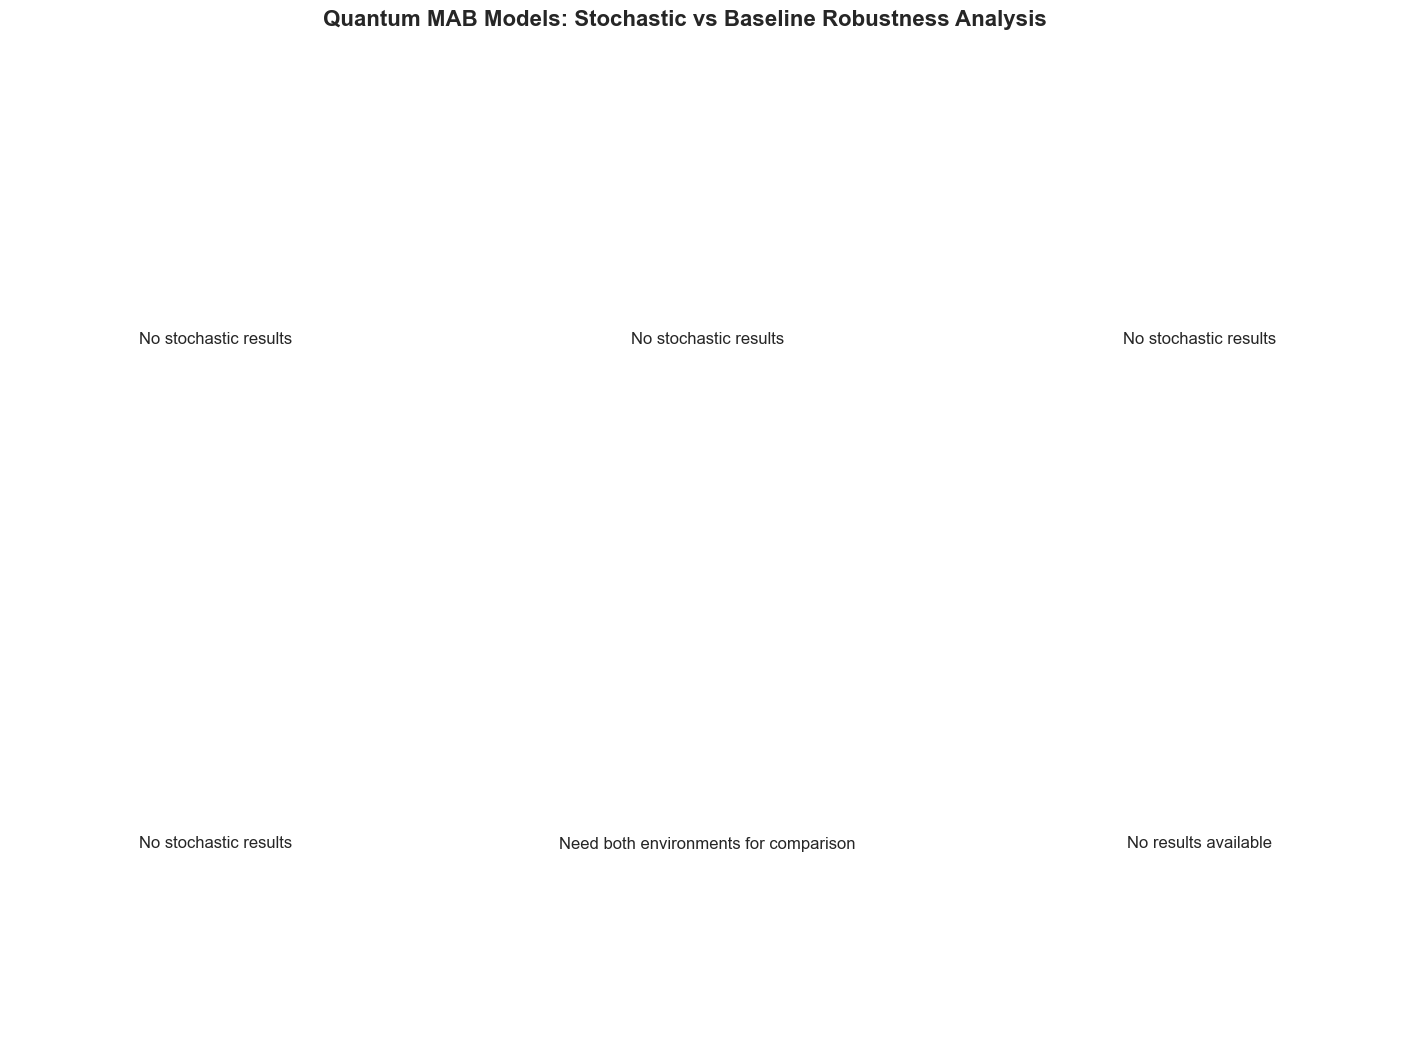

In [9]:
# @title Robustness Analysis and Quantification
import importlib
# from daqr.evaluation import visualizer

importlib.reload(visualizer)
from daqr.evaluation.visualizer import QuantumEvaluatorVisualizer

print("=" * 70)
print("ROBUSTNESS ANALYSIS")
print("=" * 70)

try:
    # Pretty print comparison results
    import pprint
    print("Comparison Results Summary:")
    # pprint.pprint(comparison_results)

    # Full comparison plot (all scenarios together)
    viz = QuantumEvaluatorVisualizer(comparison_results, allocator=allocator)
    viz.plot_stochastic_vs_adversarial_comparison()

    # Get list of all scenarios
    scenario_list = list(test_scenarios.keys())

    # Plot each scenario individually
    for scenario in scenario_list:
        if scenario.lower() == 'stochastic': pass
        print(f"\n📊 Generating plots for scenario: {scenario.upper()}")
        evaluator.calculate_scenario_performance(scenario=scenario)

        # Get ALL results for this scenario (all experiments)
        all_scenario_results = evaluator.get_evaluation_results(scenario=scenario)
        
        # Just pass the scenario name - method auto-detects and plots it
        viz.plot_scenarios_comparison(scenario=scenario)
        
        # # Also plot just the last experiment
        # if len(all_scenario_results[scenario].keys()) > 1:
        #     last_scenario_results = evaluator.get_evaluation_results(scenario=scenario,exp_id=-1)
        #     if last_scenario_results: viz.plot_scenarios_comparison(last_scenario_results)

    print("\n All scenario plots generated!")

    
    print("\n✓ Stochastic Analysis Generated:")
    print("  → quantum_mab_models_stochastic_evaluation.png")
    
    # Use viz.get_viz_data() to access pre-computed averaged results
    stoch_data = viz.get_viz_data(f'stochastic_data')
    
    if stoch_data and 'averaged' in stoch_data:
        stoch_results = stoch_data['averaged']
        
        print("\n" + "=" * 70)
        print("STOCHASTIC PERFORMANCE METRICS")
        print("=" * 70)
        
        oracle_reward = stoch_results.get('oracle_reward', 1)
        winner = stoch_results.get('winner', 'N/A')
        
        for alg in models:
            if alg in stoch_results['results']:
                model_data = stoch_results['results'][alg]
                
                # Use PRE-COMPUTED metrics
                stoch_reward = model_data.get('final_reward', 0)
                efficiency = model_data.get('efficiency', 0)
                gap = model_data.get('gap', float('inf'))
                
                print(f"\n{alg}:")
                print(f"  • Stochastic Performance: {stoch_reward:.3f}")
                print(f"  • Oracle Efficiency: {efficiency:.1f}%")
                print(f"  • Oracle Gap: {gap:.1f}%")
                
                if efficiency > 90:     classification = "EXCELLENT"
                elif efficiency > 80:   classification = "GOOD"
                elif efficiency > 70:   classification = "MODERATE"
                else:                   classification = "NEEDS IMPROVEMENT"
                
                print(f"  • Classification: {classification}")
                
                if alg == winner:
                    print(f"  ★ WINNER ★")
        
        print("\n" + "=" * 70)
        print("STOCHASTIC ENVIRONMENT INSIGHTS")
        print("=" * 70)
        print("  • Natural quantum decoherence and network failures")
        print("  • Performance metrics validate theoretical predictions")
        print("  • Baseline for future adversarial robustness studies")
    else:
        print("⚠ No stochastic averaged results available")

except Exception as e:
    print(f"❌ Error in robustness analysis: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
saved_experiments = viz.save_all_evaluation_results(save_format='both')

## Multi-Environment Performance Analysis

### Complete Evaluation Matrix

This research extends beyond the primary stochastic-adversarial comparison to provide comprehensive algorithm assessment across the complete spectrum of operational environments, establishing a thorough empirical foundation for robustness evaluation.

### Environmental Test Framework

| Environment | Classification | Threat Characteristics | Analytical Purpose |
|-------------|---------------|----------------------|-------------------|
| `none` | Baseline | Deterministic optimal conditions | Theoretical performance ceiling |
| `stochastic` | Probabilistic | Uniform random failures | Standard operational baseline |
| `markov` | Adversarial | Memory-dependent strategic attacks | Oblivious adversarial model |
| `adaptive` | Adversarial | Feedback-driven strategic attacks | Responsive adversarial model |
| `onlineadaptive` | Adversarial | Real-time adaptive strategic attacks | Sophisticated adversarial model |

### Research Contributions

**Comprehensive Threat Model Coverage**
The evaluation framework addresses the complete spectrum of operational conditions, from optimal deterministic environments through increasingly sophisticated adversarial scenarios, providing unprecedented coverage of realistic deployment conditions.

**Graduated Adversarial Complexity Analysis**  
The systematic progression from oblivious to sophisticated adversarial models enables precise quantification of algorithm performance degradation as threat sophistication increases, revealing critical robustness thresholds.

**Cross-Environment Validation Protocol**
Consistent algorithm ranking across multiple environments validates robustness claims and identifies algorithms with stable performance characteristics independent of operational conditions.

**Empirical Robustness Quantification**
The multi-environment approach enables precise measurement of performance degradation rates, establishing quantitative robustness metrics that support theoretical predictions and practical deployment decisions.

### Methodological Significance

This comprehensive evaluation protocol addresses limitations in existing literature where algorithm assessment often focuses on narrow operational scenarios, providing the empirical foundation necessary for robust algorithm deployment in practical quantum network environments.